# Lab 2 — The concurrency budget

> **Lab thesis:** a GPU is not fast because its threads are fast. It is fast because
> thousands of them are in flight at once. In this lab you *derive* how much work your
> GPU must have in flight to run at full speed — from two measurements you take
> yourself — and then find the exact grid size at which it stops being able to.

[Lecture 7](../lectures/Lecture7.md) argued this qualitatively: over-subscribe the
machine, and memory latency disappears behind other warps' arithmetic. It never put a
number on *how much* over-subscription is enough. That number is not a constant — it is
a property of your GPU, and it follows from two things you can measure: **how long one
memory access takes**, and **how many bytes per second your GPU can move**.

You will write Triton kernels to measure both, combine them with Little's Law, and
then test the prediction against the machine.

---

In [ ]:
# ---------------------------------------------------------------------------
# Setup. This lab needs Triton, so it needs an NVIDIA (CUDA) or AMD (ROCm) GPU.
# `torch.cuda` is the correct namespace on ROCm -- that is not a typo.
# Apple silicon cannot run this lab: Metal has no Triton backend.
# ---------------------------------------------------------------------------
import importlib.util, subprocess, sys

def ensure(module, spec=None):
    """Install `spec` only if `module` cannot already be imported."""
    if importlib.util.find_spec(module) is not None:
        return
    for candidate in ([spec, module] if spec and spec != module else [module]):
        print(f"installing {candidate} ...")
        if subprocess.run([sys.executable, "-m", "pip", "install", "-q", candidate]).returncode == 0:
            return
    raise RuntimeError(f"could not install {module}")

def triton_spec():
    """The exact Triton this torch build was compiled against (see Lecture 7)."""
    try:
        from importlib.metadata import requires
        for req in requires("torch") or []:
            dep = req.split(";")[0].strip()
            if "triton" in dep:
                return dep
    except Exception:
        pass
    return "triton"

ensure("torch")
ensure("matplotlib")
ensure("triton", triton_spec())

import json, math, platform, time
from datetime import datetime, timezone

import torch
import triton
import triton.language as tl
import matplotlib.pyplot as plt

assert torch.cuda.is_available(), (
    "No CUDA/ROCm GPU visible to PyTorch.\n"
    "  Colab : Runtime > Change runtime type > T4 GPU\n"
    "  NVIDIA: check `nvidia-smi`\n"
    "  AMD   : check `rocm-smi`\n"
    "  Apple : this lab cannot run on MPS -- Triton has no Metal backend."
)

P        = torch.cuda.get_device_properties(0)
DEVICE   = P.name
VENDOR   = "rocm" if torch.version.hip else "cuda"
BACKEND  = f"ROCm/HIP {torch.version.hip}" if VENDOR == "rocm" else f"CUDA {torch.version.cuda}"
WARP     = getattr(P, "warp_size", 32)
UNITS    = P.multi_processor_count
VRAM_GB  = round(P.total_memory / 1e9, 2)
ARCH     = getattr(P, "gcnArchName", None) or "sm_%d%d" % torch.cuda.get_device_capability(0)
CLOCK_GHZ = round(getattr(P, "clock_rate", 0) / 1e6, 3) or None

print(f"device   : {DEVICE}")
print(f"backend  : torch {torch.__version__}  ({BACKEND})  triton {triton.__version__}")
print(f"arch     : {ARCH}   VRAM {VRAM_GB} GB")
print(f"warp     : {WARP} threads    units reported: {UNITS}    boost clock: {CLOCK_GHZ} GHz")

# ------------------------------------------------------------------
# IDENTIFY YOURSELF -- the export file is named from this.
ROLL_NUMBER = ""      # <-- EDIT ME, e.g. "202301234"
NAME        = ""      # <-- EDIT ME
# ------------------------------------------------------------------

RESULTS = {"schema_version": 1, "lab": "lab2_concurrency_budget",
           "env": {}, "results": {}, "answers": {}}
RESULTS["env"] = {
    "device": DEVICE, "vendor": VENDOR, "backend": BACKEND, "torch": torch.__version__,
    "triton": triton.__version__, "arch": str(ARCH), "vram_gb": VRAM_GB,
    "warp_size": WARP, "multi_processor_count": UNITS, "clock_ghz_reported": CLOCK_GHZ,
    "platform": platform.platform(),
    "started_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
}
if not ROLL_NUMBER:
    print("\n>>> Set ROLL_NUMBER and NAME above before exporting. <<<")

### ⚡ Preflight — power, before you run anything heavy

Same warning as Lab 5/6, and for the same reason. Part 4 of this lab holds the GPU at
sustained peak for several seconds at a time.

In [ ]:
import glob, os, subprocess

def on_ac_power():
    """True on mains, False on battery, None if undetectable (Colab, some VMs)."""
    found = False
    for online in glob.glob("/sys/class/power_supply/*/online"):
        try:
            kind = open(os.path.join(os.path.dirname(online), "type")).read().strip()
            if kind != "Mains":
                continue
            found = True
            if open(online).read().strip() == "1":
                return True
        except OSError:
            continue
    if found:
        return False
    if platform.system() == "Darwin":
        try:
            out = subprocess.run(["pmset", "-g", "batt"], capture_output=True,
                                 text=True, timeout=5).stdout
            if "AC Power" in out:      return True
            if "Battery Power" in out: return False
        except Exception:
            pass
    return None

AC = on_ac_power()
SAFE_MODE = (AC is False)

if AC is None:
    print("power source : not detectable (cloud/VM - fine, nothing to worry about)")
elif AC:
    print("power source : AC / mains  OK")
else:
    print("power source : BATTERY  !!")
    print("               Sustained peak GPU load on battery can brown the machine out")
    print("               and reboot it instantly, with no logs.")
    print("               >>> Plug in the charger and re-run this cell. <<<")

# Every sweep below is sized from these.
STREAM_MB   = 64 if SAFE_MODE else 256      # buffer for the bandwidth sweep
CHASE_STEPS = 512 if SAFE_MODE else 1024    # dependent loads per timed chase
WAVE_ITERS  = 2048 if SAFE_MODE else 4096   # arithmetic per block in Part 4
WAVE_MAX    = 3 if SAFE_MODE else 4         # sweep grid up to WAVE_MAX x UNITS x 2

print(f"\nSAFE_MODE   : {SAFE_MODE}")
print(f"stream buffer: {STREAM_MB} MB   chase steps: {CHASE_STEPS}   part-4 iters: {WAVE_ITERS}")

RESULTS["env"].update({"ac_power": AC, "safe_mode": SAFE_MODE})

### The stopwatch

Every timing in this lab goes through one helper. `triton.testing.do_bench` warms up
(the first call to a Triton kernel *compiles* it), runs the kernel many times, and
returns the **median** — not the mean, because a single scheduler hiccup or clock
change would drag a mean around.

It also synchronises for you. If you time a kernel launch with `time.perf_counter()`
and no `torch.cuda.synchronize()`, you measure the doorbell, not the work — that is
Lecture 7 Depth 1, and Lab 5/6 Part 2.

In [ ]:
def bench(fn, warmup=10, rep=50):
    """Median milliseconds over `rep` timed runs, after `warmup` untimed ones."""
    return triton.testing.do_bench(fn, warmup=warmup, rep=rep, return_mode="median")

def record(key, value):
    """Put a measurement in the export and echo it, so the JSON is never a mystery."""
    RESULTS["results"][key] = value
    return value

---

## Part 0 — What am I measuring on? *(5 marks)*

Before any measurement means anything, you need to know what the machine claims to be.
Lecture 7 flagged one trap here and you are about to walk into it: **`multi_processor_count`
does not mean the same thing on every vendor.** On NVIDIA it counts SMs. On AMD RDNA it
counts *work-group processors*, each of which contains two compute units — so a 36-CU
card reports 18.

Record what the machine says now. In Part 4 you will measure the same quantity from the
outside and find out which reading was the useful one.

In [ ]:
threads_per_unit = P.max_threads_per_multi_processor
resident = threads_per_unit * UNITS

print(f"units reported (multi_processor_count) : {UNITS}")
print(f"max threads resident per unit          : {threads_per_unit:,}")
print(f"max threads resident on the whole GPU  : {resident:,}  ({resident // WARP:,} warps)")
print(f"warp / wavefront width                 : {WARP}")
print(f"reported boost clock                   : {CLOCK_GHZ} GHz")
print(f"total VRAM                             : {VRAM_GB} GB")

record("units_reported", UNITS)
record("threads_per_unit", threads_per_unit)
record("resident_threads", resident)
record("warp_size", WARP)

📝 **Task 0.1 — what does your GPU claim?** *(5 marks)*

- Report `units_reported`, `resident_threads`, and your warp width.
- Look up your GPU's marketing specification. How many **compute units / SMs** does the
  vendor say it has, and does that agree with `units_reported`? If it does not, say by
  what factor and why.
- Write down, now, what you think Part 4 will measure the scheduling unit count to be.
  You are allowed to be wrong; you are not allowed to skip it.

*Your answer:*

---

## Part 1 — How long is one memory access? *(20 marks)*

Latency is the hardest of the two numbers to measure, because the GPU is built
specifically to stop you from seeing it. Issue a hundred independent loads and the
memory system will overlap them; you will measure throughput, not latency.

So you have to build a load the machine **cannot** overlap: a chain where each
access's *address* is the previous access's *value*. That is a **pointer chase**.
The buffer is filled with a single permutation cycle — `buf[i]` holds the index of
the next hop — so the hardware has no way to start hop *n+1* until hop *n* has come
back.

One thread. One block. The entire GPU idle except a single lane. That is deliberate:
you are measuring the *unhidden* cost of one access, which is exactly the quantity
latency hiding exists to conceal.

We vary the size of the buffer being chased. A small buffer fits in cache and the
chase is quick; a large one misses everything and pays full freight.

### 🔮 Predict first — Task 1.1 *(5 marks)*

📝 **Before running the next cell**: sketch the shape you expect from a plot of
*latency per access* against *buffer footprint*, from 8 KB to 512 MB. How many
distinct flat regions ("plateaus") do you expect, and what sets the footprint at
which each step happens? Give a rough guess in nanoseconds for the fastest and the
slowest.

*Your prediction:*

In [ ]:
@triton.jit
def chase(buf_ptr, out_ptr, STEPS: tl.constexpr):
    """One lane walking a pointer cycle: STEPS strictly dependent loads.

    Each iteration's address comes from the previous iteration's loaded value, so
    the memory system cannot start one hop before the last has returned. The store
    at the end exists only so the compiler cannot delete the whole loop as dead.
    """
    idx = tl.zeros([1], dtype=tl.int32)
    for _ in range(STEPS):
        idx = tl.load(buf_ptr + idx)
    tl.store(out_ptr + tl.zeros([1], dtype=tl.int32), idx)


def make_ring(n_elem, stride_elem=32):
    """A buffer holding ONE permutation cycle, hopping `stride_elem` elements apart.

    The stride matters: hops land 128 B apart so no two consecutive hops share a
    cache line. A stride of 1 would let one fetched line serve many hops and you
    would measure the cache, not the memory.
    """
    n_hops = n_elem // stride_elem
    nxt = ((torch.arange(n_hops, dtype=torch.int32) + 1) % n_hops) * stride_elem
    buf = torch.zeros(n_elem, dtype=torch.int32)
    buf[torch.arange(n_hops, dtype=torch.long) * stride_elem] = nxt
    return buf.cuda()


out = torch.zeros(1, dtype=torch.int32, device="cuda")
footprints_kb = [8, 16, 32, 64, 128, 256, 512, 1024, 4096, 16384, 65536]
if not SAFE_MODE:
    footprints_kb += [262144]

lat_kb, lat_ns = [], []
print(" footprint      ns/access    cycles")
for kb in footprints_kb:
    n_elem = kb * 1024 // 4
    if n_elem < 32 * 8:                      # too small for a meaningful cycle
        continue
    if kb * 1024 > 0.25 * P.total_memory:    # never fill VRAM
        break
    buf = make_ring(n_elem)
    ms = bench(lambda: chase[(1,)](buf, out, STEPS=CHASE_STEPS), warmup=5, rep=25)
    ns = ms * 1e6 / CHASE_STEPS
    cyc = ns * CLOCK_GHZ if CLOCK_GHZ else float("nan")
    lat_kb.append(kb); lat_ns.append(ns)
    print(f"  {kb:8d} KB   {ns:8.1f}     {cyc:7.0f}")
    del buf; torch.cuda.empty_cache()

L_FAST = min(lat_ns)
L_MEM  = lat_ns[-1]                          # the largest footprint you measured
record("latency_footprint_kb", lat_kb)
record("latency_ns", [round(v, 2) for v in lat_ns])
record("latency_fastest_ns", round(L_FAST, 2))
record("latency_memory_ns", round(L_MEM, 2))
print(f"\nfastest (cache-resident) : {L_FAST:7.1f} ns")
print(f"slowest (memory-resident): {L_MEM:7.1f} ns    ->  {L_MEM / L_FAST:.1f}x")

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(lat_kb, lat_ns, "o-", color="crimson")
ax.set_xscale("log", base=2)
ax.set_xlabel("footprint being chased (KB, log scale)")
ax.set_ylabel("latency per access (ns)")
ax.set_title(f"Unhidden memory latency — {DEVICE}")
ax.grid(alpha=0.3)
ax.set_ylim(bottom=0)
for kb, ns in zip(lat_kb, lat_ns):
    ax.annotate(f"{ns:.0f}", (kb, ns), textcoords="offset points",
                xytext=(0, 7), ha="center", fontsize=8)
plt.tight_layout(); plt.show()

📝 **Task 1.2 — read the staircase** *(9 marks)*

- How many plateaus does your plot have? Give the footprint range and the latency of each.
- Name the level of the memory hierarchy you believe each plateau corresponds to, and
  justify it from the footprint at which the step occurs — not from what you expect the
  answer to be. Your GPU's cache sizes are published; look them up and compare.
- If two levels you expected to see are indistinguishable in your data, say so and give a
  reason why they might have the same latency. **Reporting a missing step honestly scores
  full marks; inventing one scores zero.**

*Your answer:*

📝 **Task 1.3 — latency in the only unit that matters** *(6 marks)*

Nanoseconds are a human unit. The scheduler thinks in cycles.

- Convert your slowest latency to **clock cycles** using the reported boost clock.
- A fused multiply-add is one instruction. Roughly how many arithmetic instructions
  could one lane have issued during the time it spent waiting for that one load?
- Lecture 7 said the GPU "runs somebody else" during that wait. Using your own number,
  how many *other* warps would have to be ready to issue in order to fill the hole
  completely, assuming each one can issue an instruction every cycle?

*Your answer:*

AMD Radeon RX 6700M: L2 = 3072 KB, 18 SMs
 footprint    ns/hop   SM GHz   cycles
         8 KB     36.1    2.03        73
        16 KB     35.3    2.46        87
        24 KB     54.2    2.46       133
        32 KB     54.4    2.46       134
        48 KB     52.7    2.46       130
        64 KB     54.1    2.46       133
        96 KB     54.9    2.46       135
       128 KB     54.2    2.46       134
       256 KB     94.6    2.46       233
       512 KB    149.2    2.46       368
      1024 KB    301.4    2.44       737
      2048 KB    274.0    2.46       675
      3072 KB    275.9    2.46       680
      4096 KB    324.8    2.46       801
      6144 KB    272.3    2.46       671
      8192 KB    272.9    2.46       673
     16384 KB    275.8    2.46       680
     65536 KB    265.0    2.46       653
    262144 KB    295.4    2.46       728

fastest :    35.3 ns
slowest :   295.4 ns   ->  8.4x


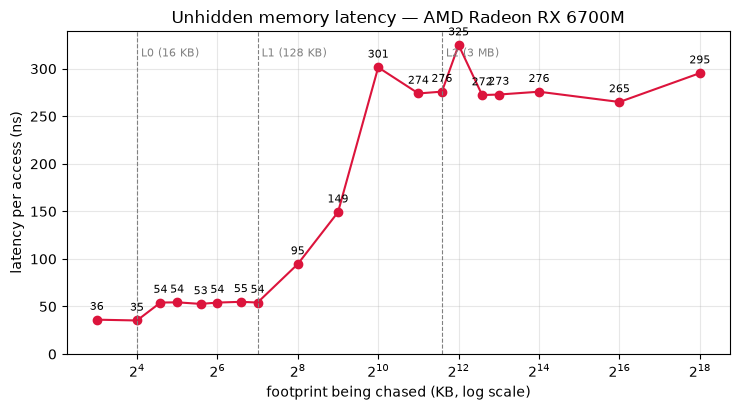

In [4]:
"""Pointer-chase latency on a GPU, done carefully.

Changes from the first version:
  1. The ring is a RANDOM single cycle over cache lines (not sequential), so DRAM
     row-buffer hits and any streaming heuristics cannot flatter the memory number.
  2. STEPS is a runtime argument, not constexpr, so the loop is guaranteed to stay a
     loop (no unrolling into hundreds of KB of SASS that thrashes the I-cache).
  3. Latency is the SLOPE between two step counts, which cancels launch overhead.
  4. num_warps=1 so a single warp walks the chain instead of four redundant ones.
  5. The actual SM clock is read per footprint (if pynvml is present) so cycles are
     computed from what the GPU was really running at, not a constant.
"""
import torch, triton, triton.language as tl
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------- kernel
@triton.jit
def chase(buf_ptr, out_ptr, steps):
    idx = tl.zeros([1], dtype=tl.int32)
    for _ in range(steps):                      # runtime bound -> real loop
        idx = tl.load(buf_ptr + idx)            # add cache_modifier=".cg" to bypass L1
    tl.store(out_ptr + tl.zeros([1], dtype=tl.int32), idx)


# ------------------------------------------------------------------------------- ring
def make_random_ring(n_elem, stride_elem=32, seed=0):
    """One permutation cycle visiting every line exactly once, in random order.

    Line i (element i*stride) stores the element index of the line that follows it.
    Because the visiting order is a random permutation, consecutive hops are in
    unrelated rows/pages: this is a latency test, not a streaming test.
    """
    n_hops = n_elem // stride_elem
    g = torch.Generator().manual_seed(seed)
    order = torch.randperm(n_hops, generator=g)            # visiting order of lines
    nxt = torch.empty(n_hops, dtype=torch.int64)
    nxt[order] = torch.roll(order, -1)                     # order[k] -> order[k+1]
    buf = torch.zeros(n_elem, dtype=torch.int32)
    buf[torch.arange(n_hops) * stride_elem] = (nxt * stride_elem).to(torch.int32)
    return buf.cuda()


# ----------------------------------------------------------------------------- timing
def bench_ms(fn, warmup=5, rep=25):
    return triton.testing.do_bench(fn, warmup=warmup, rep=rep)

def hop_ns(buf, out, steps_a=2048, steps_b=8192):
    """Slope of time vs. steps: (t_b - t_a) / (b - a). Launch overhead cancels."""
    run = lambda s: chase[(1,)](buf, out, s, num_warps=1)
    ta = bench_ms(lambda: run(steps_a))
    tb = bench_ms(lambda: run(steps_b))
    return (tb - ta) * 1e6 / (steps_b - steps_a)

# def sm_clock_ghz():
#     try:
#         import pynvml
#         pynvml.nvmlInit()
#         h = pynvml.nvmlDeviceGetHandleByIndex(torch.cuda.current_device())
#         return pynvml.nvmlDeviceGetClockInfo(h, pynvml.NVML_CLOCK_SM) / 1e3
#     except Exception:
#         return float("nan")

import glob, os

def _sysfs_dev_for_torch():
    p = torch.cuda.get_device_properties(0)
    want = f"{p.pci_domain_id:04x}:{p.pci_bus_id:02x}:{p.pci_device_id:02x}.0"
    for dev in glob.glob("/sys/class/drm/card*/device"):
        if os.path.realpath(dev).endswith(want):
            return dev
    return None  # older torch lacks pci_* fields; then hard-code /sys/class/drm/card1/device

SYSFS_DEV = _sysfs_dev_for_torch()

def sm_clock_ghz():
    """Current sclk from pp_dpm_sclk; the active level is marked with '*'."""
    try:
        for line in open(f"{SYSFS_DEV}/pp_dpm_sclk"):
            if line.strip().endswith("*"):
                return float(line.split(":")[1].split("Mhz")[0]) / 1e3
    except Exception:
        pass
    return float("nan")     
# ------------------------------------------------------------------------------- main
P = torch.cuda.get_device_properties(0)
out = torch.zeros(1, dtype=torch.int32, device="cuda")

# Dense around the L1 (32/64 KB) and L2 (4 MB on T4) edges.
footprints_kb = [8, 16, 24, 32, 48, 64, 96, 128, 256, 512, 1024,
                 2048, 3072, 4096, 6144, 8192, 16384, 65536, 262144]

print(f"{P.name}: L2 = {P.L2_cache_size // 1024} KB, {P.multi_processor_count} SMs")
print(" footprint    ns/hop   SM GHz   cycles")
results = []
for kb in footprints_kb:
    n_elem = kb * 1024 // 4
    if n_elem < 32 * 8 or kb * 1024 > 0.25 * P.total_memory:
        continue
    buf = make_random_ring(n_elem)
    ns = hop_ns(buf, out)
    ghz = sm_clock_ghz()                    # read right after the run
    results.append((kb, ns))
    print(f"  {kb:8d} KB  {ns:7.1f}   {ghz:5.2f}   {ns * ghz:7.0f}")
    del buf; torch.cuda.empty_cache()

lat_kb = [kb for kb, _ in results]
lat_ns = [ns for _, ns in results]
print(f"\nfastest : {min(lat_ns):7.1f} ns")
print(f"slowest : {lat_ns[-1]:7.1f} ns   ->  {lat_ns[-1] / min(lat_ns):.1f}x")

# ------------------------------------------------------------------------- plot
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(lat_kb, lat_ns, "o-", color="crimson")
ax.set_xscale("log", base=2)
ax.set_xlabel("footprint being chased (KB, log scale)")
ax.set_ylabel("latency per access (ns)")
ax.set_title(f"Unhidden memory latency \u2014 {P.name}")
ax.grid(alpha=0.3)
ax.set_ylim(bottom=0)
# mark the cache edges so the shelves are readable at a glance
# for x, label in [(64, "L1 (64 KB)"), (P.L2_cache_size // 1024, "L2")]:
#     ax.axvline(x, color="gray", ls="--", lw=0.8)
#     ax.text(x, ax.get_ylim()[1] * 0.95, f" {label}", fontsize=8,
#             color="gray", va="top")
def cache_edges_kb(P):
    """[(label, KB)] cache capacities for the current device, best effort."""
    edges = []
    if torch.version.hip:
        arch = getattr(P, "gcnArchName", "")            # e.g. "gfx1031"
        if arch.startswith("gfx10"):                     # RDNA1/2
            edges += [("L0 (16 KB)", 16), ("L1 (128 KB)", 128)]
        elif arch.startswith("gfx11"):                   # RDNA3
            edges += [("L0 (32 KB)", 32), ("L1 (256 KB)", 256)]
        elif arch.startswith("gfx9"):                    # Vega / CDNA
            edges += [("L1 (16 KB)", 16)]
    else:
        unified = getattr(P, "shared_memory_per_multiprocessor", None)
        if unified is None:                              # older torch: table by CC
            unified = {7: 96, 8: 128, 9: 256}.get(P.major, None)
            if P.major == 7 and P.minor == 0: unified = 128     # V100
            if P.major == 8 and P.minor == 0: unified = 192     # A100
            unified = unified and unified * 1024
        if unified:
            edges += [(f"L1 (\u2264{unified // 1024} KB)", unified // 1024)]
    if P.L2_cache_size:
        edges += [(f"L2 ({P.L2_cache_size // 1024 // 1024} MB)", P.L2_cache_size // 1024)]
    if torch.version.hip and getattr(P, "gcnArchName", "").startswith(("gfx103", "gfx11")):
        edges += [("Infinity Cache?", None)]             # size unknown to the driver
    return [(l, kb) for l, kb in edges if kb]

for label, x in cache_edges_kb(P):
    ax.axvline(x, color="gray", ls="--", lw=0.8)
    ax.text(x, ax.get_ylim()[1] * 0.95, f" {label}", fontsize=8, color="gray", va="top")
    
for kb, ns in zip(lat_kb, lat_ns):
    ax.annotate(f"{ns:.0f}", (kb, ns), textcoords="offset points",
                xytext=(0, 7), ha="center", fontsize=8)
plt.tight_layout(); plt.show()

---

## Part 2 — How many bytes per second can you actually move? *(15 marks)*

The second half of the budget. This time you want the opposite of Part 1: as many
independent accesses in flight as possible, so the memory system can overlap them all
and show you its ceiling.

The kernel is a **grid-stride copy**. The size of the data is fixed; the number of
blocks is not. One block means one unit of the GPU is working and the rest are idle.
Many blocks mean the machine is saturated. Sweeping the block count therefore sweeps
*how much work is in flight* — which is precisely the axis Part 3 needs.

### 🔮 Predict first — Task 2.1 *(4 marks)*

📝 **Before running the next cell**: the sweep below launches the same copy with 1, 2,
4, ... up to a few thousand blocks. Sketch the curve of achieved GB/s against block
count. Where does it stop rising, and what — in one sentence — stops it? Does it ever
come back *down*, and if so why might it?

*Your prediction:*

In [ ]:
@triton.jit
def stream(x_ptr, y_ptr, n, BLOCK: tl.constexpr):
    """Grid-stride copy. However many blocks you launch, the whole array gets copied;
    the launch configuration decides only how much of it is in flight at once."""
    pid, nprog = tl.program_id(0), tl.num_programs(0)
    for base in range(pid * BLOCK, n, nprog * BLOCK):
        offs = base + tl.arange(0, BLOCK)
        m = offs < n
        tl.store(y_ptr + offs, tl.load(x_ptr + offs, mask=m), mask=m)


BLOCK_ELEMS = 1024          # elements each block touches per grid-stride step
NUM_WARPS   = 4
N = STREAM_MB * 1024 * 1024 // 4
x = torch.randn(N, device="cuda")
y = torch.empty_like(x)
moved = 2 * N * 4           # one read + one write per element, 4 B each

grids = sorted({1, 2, 4, 8, UNITS, 2*UNITS, 4*UNITS, 8*UNITS,
                16*UNITS, 64*UNITS, 256*UNITS})

bw_blocks, bw_gbs = [], []
print("  blocks    warps      ms      GB/s")
for blocks in grids:
    ms = bench(lambda: stream[(blocks,)](x, y, N, BLOCK=BLOCK_ELEMS, num_warps=NUM_WARPS),
               warmup=5, rep=30)
    gbs = moved / (ms * 1e-3) / 1e9
    bw_blocks.append(blocks); bw_gbs.append(gbs)
    print(f"  {blocks:6d}  {blocks*NUM_WARPS:7d}  {ms:8.3f}  {gbs:8.1f}")

BW_PEAK = max(bw_gbs)
record("bw_blocks", bw_blocks)
record("bw_gbs", [round(v, 2) for v in bw_gbs])
record("bw_peak_gbs", round(BW_PEAK, 2))
record("bw_one_block_gbs", round(bw_gbs[0], 2))
print(f"\npeak achieved : {BW_PEAK:.1f} GB/s")
print(f"one block only: {bw_gbs[0]:.1f} GB/s   ->  {BW_PEAK / bw_gbs[0]:.0f}x left on the table")

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(bw_blocks, bw_gbs, "o-", color="tab:blue")
ax.axhline(BW_PEAK, ls="--", lw=1, color="grey")
ax.annotate(f"peak {BW_PEAK:.0f} GB/s", (bw_blocks[-1], BW_PEAK),
            textcoords="offset points", xytext=(-10, 6), ha="right", fontsize=9, color="grey")
ax.set_xscale("log", base=2)
ax.set_xlabel("blocks launched (log scale)")
ax.set_ylabel("achieved bandwidth (GB/s)")
ax.set_title(f"Bandwidth against work in flight — {DEVICE}")
ax.grid(alpha=0.3); ax.set_ylim(bottom=0)
plt.tight_layout(); plt.show()

📝 **Task 2.2 — the ceiling and the ramp** *(11 marks)*

- Report your peak achieved bandwidth, and look up your GPU's **theoretical** memory
  bandwidth. What fraction of it did you reach? (60–85% is normal. Above 100% means the
  benchmark is broken, not that your GPU is special — most often because the array fits
  in cache. Check `STREAM_MB` against your last-level cache before you celebrate.)
- The left end of the curve is nearly a straight line on a log axis: doubling the blocks
  doubles the bandwidth. Explain why that region is linear, in terms of what each
  additional block contributes.
- The right end is flat. Name what is saturated there, and explain why adding a thousand
  more blocks cannot help.

*Your answer:*

---

## Part 3 — Little's Law: how much must be in flight? *(25 marks)*

You now have both halves of the budget:

- **λ** — bandwidth, the rate the memory system can deliver bytes (Part 2)
- **W** — latency, how long each byte takes to arrive (Part 1)

Little's Law says that for a system in steady state, the amount of work resident inside
it is the arrival rate times the residence time:

```text
bytes in flight  =  bandwidth  x  latency
```

This is not a GPU fact. It is a queueing-theory identity that holds for supermarket
checkouts and hospital beds. Applied here it answers the question Lecture 7 left open:
*to run at full bandwidth, a GPU must have this many bytes requested-but-not-yet-arrived
at every instant.* Fewer, and the memory system is idle part of the time — no matter how
fast your arithmetic is.

The point of this part is that you can now **predict the knee of the Part 2 curve
without looking at it**, and then check.

### 🔮 Predict first — Task 3.1 *(6 marks)*

📝 **Before running the next cell**, do the arithmetic by hand:

1. Multiply your Part 2 peak bandwidth by your Part 1 memory latency. Convert to KB.
2. Each block in the Part 2 kernel has `BLOCK_ELEMS = 1024` four-byte elements in flight
   per grid-stride step. How many **blocks** does your answer to (1) correspond to?
3. That is your predicted knee. Write it down before you run the cell.

*Your prediction (bytes in flight, and blocks):*

In [ ]:
# ---- the derivation ------------------------------------------------------
lat_s   = L_MEM * 1e-9
bw_Bs   = BW_PEAK * 1e9
need_B  = bw_Bs * lat_s                       # Little's Law
need_blocks = need_B / (BLOCK_ELEMS * 4)      # bytes each block has outstanding

print("DERIVED from your own two measurements")
print(f"  bandwidth        : {BW_PEAK:10.1f} GB/s")
print(f"  latency          : {L_MEM:10.1f} ns")
print(f"  bytes in flight  : {need_B/1024:10.1f} KB")
print(f"  -> blocks needed : {need_blocks:10.1f}")
print(f"  -> warps needed  : {need_blocks * NUM_WARPS:10.1f}")

# ---- what the machine actually did ---------------------------------------
# The knee: the smallest block count that reached 95% of your peak.
knee_blocks = next(b for b, g in zip(bw_blocks, bw_gbs) if g >= 0.95 * BW_PEAK)
knee_B = knee_blocks * BLOCK_ELEMS * 4

print("\nMEASURED from the Part 2 sweep")
print(f"  knee at          : {knee_blocks:10d} blocks   ({knee_blocks*NUM_WARPS} warps)")
print(f"  bytes in flight  : {knee_B/1024:10.1f} KB")

ratio = knee_B / need_B
print(f"\nmeasured / predicted = {ratio:.2f}x")
print("  (within ~3x is a good result -- see Task 3.2 for why it is not exactly 1)")

record("littles_law_bytes_needed", round(need_B, 1))
record("littles_law_blocks_needed", round(need_blocks, 2))
record("knee_blocks_measured", knee_blocks)
record("knee_bytes_measured", knee_B)
record("littles_law_ratio", round(ratio, 3))

📝 **Task 3.2 — defend or explain the number** *(19 marks)*

- State your predicted and measured bytes-in-flight and the ratio between them.
- **The ratio is almost never exactly 1, and the reasons are the interesting part.**
  Work through at least three of these and say which apply to *your* number and in
  which direction each pushes it:
    - the latency you measured was for a *dependent scalar* load; the bandwidth kernel
      issues *vector* loads of a full warp's width at once
    - one block does not have only one load outstanding — the compiler unrolls the
      grid-stride loop, so several requests per block can be in flight simultaneously
    - the Part 1 chase defeated every prefetcher on the chip; the Part 2 stream is the
      most prefetch-friendly access pattern there is
    - your `L_MEM` may still be a cache latency if `STREAM_MB` fits in last-level cache
    - the knee is defined here as "95% of peak", which is a choice, not a fact
- Finally, the payoff: **a colleague's kernel runs at 30% of peak bandwidth and they
  propose to fix it by optimising the arithmetic in the inner loop.** Using your two
  numbers, explain in three sentences why that is likely to change nothing, and what
  you would measure instead.

*Your answer:*

---

## Part 4 — The staircase: measuring the scheduling quantum *(25 marks)*

Everything so far has been about *memory*. This part is about the *scheduler*, and it
is the part with the sharpest result in the lab.

The kernel below gives every block **exactly the same fixed amount of arithmetic** and
no memory traffic worth speaking of. So the total runtime cannot depend on how much data
there is — it can only depend on how many blocks the GPU can run **at the same time**,
and therefore on how many sequential *rounds* of blocks it needs.

If the GPU can hold *R* blocks resident, then launching anything from 1 to *R* blocks
should take **the same wall-clock time** — the extra blocks ride along for free. Block
*R+1* has nowhere to go and must wait for a slot, so the time jumps.

The result is a staircase, and the width of its steps is a number the vendor does not
print on the box.

### 🔮 Predict first — Task 4.1 *(5 marks)*

📝 **Before running the next cell**: you are about to time the same fixed-work kernel at
every block count from 1 to about `4 x 2 x units`. Sketch the curve. Is it a straight
line, a staircase, or smooth-with-a-knee? If you predict steps, how wide do you expect
them to be, and what should the step width equal?

*Your prediction:*

In [ ]:
@triton.jit
def fixed_work(out_ptr, BLOCK: tl.constexpr, ITERS: tl.constexpr):
    """Every block does identical work: no loads, no dependence on the grid size.

    The `maximum` is not decoration. `y = y*c + d` repeated ITERS times has a closed
    form and the compiler will find it, silently deleting the work you are timing.
    Clamping the chain each iteration keeps it honest -- if your staircase comes out
    flat at ~0 ms, this is the first thing to suspect.
    """
    offs = tl.program_id(0) * BLOCK + tl.arange(0, BLOCK)
    y = offs.to(tl.float32)
    for _ in range(ITERS):
        y = tl.maximum(y * 1.0000001 + 1.0, 0.0) * 0.9999
    tl.store(out_ptr + offs, y)


BLOCK_W  = 256
MAX_GRID = WAVE_MAX * 2 * UNITS + 4
out_w = torch.empty(BLOCK_W * (MAX_GRID + 1), device="cuda")

st_blocks, st_ms = [], []
for blocks in range(1, MAX_GRID + 1):
    ms = bench(lambda: fixed_work[(blocks,)](out_w, BLOCK=BLOCK_W, ITERS=WAVE_ITERS,
                                             num_warps=NUM_WARPS),
               warmup=5, rep=20)
    st_blocks.append(blocks); st_ms.append(ms)

# Locate the steps: a jump is a block count whose time exceeds its predecessor by 10%.
jumps = [b for b, prev, cur in zip(st_blocks[1:], st_ms[:-1], st_ms[1:]) if cur > 1.10 * prev]
gaps  = [b - a for a, b in zip(jumps[:-1], jumps[1:])]
period = max(set(gaps), key=gaps.count) if gaps else None
first_plateau = (jumps[0] - 1) if jumps else None

print(f"time at 1 block        : {st_ms[0]*1e3:8.1f} us")
print(f"time at {MAX_GRID} blocks      : {st_ms[-1]*1e3:8.1f} us   "
      f"({st_ms[-1]/st_ms[0]:.1f}x the time for {MAX_GRID}x the work)")
print(f"\nsteps found at block counts : {jumps}")
print(f"gaps between steps          : {gaps}")
print(f"-> step period (blocks)     : {period}")
print(f"-> first plateau is         : {first_plateau} blocks wide")
if period and first_plateau:
    print(f"-> blocks resident per unit : {first_plateau / period:.1f}")
print(f"\nunits reported by PyTorch   : {UNITS}")

record("staircase_blocks", st_blocks)
record("staircase_ms", [round(v, 5) for v in st_ms])
record("staircase_jumps", jumps)
record("staircase_period", period)
record("staircase_first_plateau", first_plateau)

In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.step(st_blocks, [m*1e3 for m in st_ms], where="post", color="tab:green")
for j in jumps:
    ax.axvline(j - 0.5, ls=":", lw=1, color="crimson")
ax.axvline(UNITS, ls="--", lw=1.2, color="black")
ax.annotate(f"multi_processor_count = {UNITS}", (UNITS, max(st_ms)*1e3),
            textcoords="offset points", xytext=(6, -12), fontsize=9)
ax.set_xlabel("blocks launched (identical work in each)")
ax.set_ylabel("wall-clock time (us)")
ax.set_title(f"Wave quantisation — {DEVICE}"
             + (f"  (step period = {period} blocks)" if period else ""))
ax.grid(alpha=0.3); ax.set_ylim(bottom=0)
plt.tight_layout(); plt.show()

📝 **Task 4.2 — read the staircase** *(12 marks)*

- Report the step period and the width of the first plateau.
- **The first plateau is usually wider than the period.** Divide one by the other. What
  does that integer mean physically — what is the GPU doing with those extra blocks?
- Take two block counts on the same tread of the staircase, say the first and last.
  Report both times and both amounts of work done. State plainly how much extra work the
  larger one performed *for no extra time at all*.
- Now the reverse: find the block count just past a step. It does a few percent more work
  than the one before it. How much more time did it take? This is the **tail effect**, and
  it is the reason a batch size of 257 can be measurably slower than 256.

*Your answer:*

📝 **Task 4.3 — settle Part 0's argument** *(13 marks)*

In Part 0 you recorded what PyTorch *claims* about your GPU's unit count, and you were
warned that the claim is vendor-dependent. You have now measured a related number from
the outside, without asking the driver anything.

- Compare your step period to `multi_processor_count`. Do they agree, differ by exactly
  2, or differ by something else?
- If they disagree: which of the two would you use to choose a grid size, and why? Give
  the reasoning, not the answer — a factor of two in this number is a factor of two in
  the launch configuration of every kernel you will ever write.
- Your prediction in Task 0.1 was either right or wrong. Say which, and what you now
  think you were reasoning from.
- **A caution to address explicitly:** the period you measured is the period *for this
  kernel, at this `num_warps`, with this register usage*. Suggest one concrete change to
  the kernel that you would expect to change the period, and say which direction it
  would move.

*Your answer:*

---

## Part 5 — Spend the budget *(10 marks)*

Two numbers, one design rule.

In [ ]:
if period and first_plateau:
    R = first_plateau                         # blocks that run concurrently
    awkward = R + 1                           # one block past a full tread
    i_full, i_awk = R - 1, awkward - 1
    t_full, t_awk = st_ms[i_full], st_ms[i_awk]
    print(f"launching {R:4d} blocks : {t_full*1e3:8.1f} us")
    print(f"launching {awkward:4d} blocks : {t_awk*1e3:8.1f} us")
    print(f"  work   +{100*(awkward/R - 1):5.1f}%")
    print(f"  time   +{100*(t_awk/t_full - 1):5.1f}%   <- the tail")

    top = min(2 * R, st_blocks[-1])
    print(f"\nand the other way round:")
    print(f"launching {top:4d} blocks : {st_ms[top-1]*1e3:8.1f} us")
    print(f"  vs {awkward} blocks   : {t_awk*1e3:8.1f} us")
    print(f"  work  +{100*(top/awkward - 1):5.1f}%   time +{100*(st_ms[top-1]/t_awk - 1):5.1f}%")

    record("tail_full_blocks", R)
    record("tail_full_us", round(t_full*1e3, 2))
    record("tail_awkward_us", round(t_awk*1e3, 2))
    record("tail_penalty_pct", round(100*(t_awk/t_full - 1), 2))
else:
    print("No steps were detected, so the tail effect cannot be quantified here.")
    print("Say so in Task 5.1 -- an honest null result is marked as a result.")
    record("tail_penalty_pct", None)

📝 **Task 5.1 — the rule you would give a colleague** *(10 marks)*

Write the design rule your four measurements support, in **no more than six sentences**,
addressed to someone who writes CUDA or Triton kernels but has never measured any of
this. It must contain:

- a rule for **how much work to keep in flight**, justified by Parts 1–3;
- a rule for **how to choose a grid size**, justified by Part 4;
- one sentence on what your rule does *not* cover — a workload or a machine where you
  would expect it to fail.

Vague advice ("use more threads") scores nothing. The rule must reference your own
numbers.

*Your answer:*

---

In [ ]:
# Short-form answers. Fill every field. These are cross-checked against your own
# recorded measurements, so answer from your data, not from the lecture notes.
ANSWERS = {
    # Part 0/4 -- the unit count argument
    "units_reported":            None,   # int, from Part 0
    "vendor_claimed_cus":        None,   # int, from your GPU's spec sheet
    "staircase_period_blocks":   None,   # int, from Part 4
    "blocks_resident_per_unit":  None,   # int, first plateau / period

    # Part 1
    "latency_fastest_ns":        None,   # float
    "latency_memory_ns":         None,   # float
    "latency_memory_cycles":     None,   # int
    "n_plateaus_seen":           None,   # int

    # Part 2
    "bw_peak_gbs":               None,   # float, measured
    "bw_theoretical_gbs":        None,   # float, from the spec sheet
    "bw_fraction_of_peak":       None,   # float, 0-1

    # Part 3
    "bytes_in_flight_needed_kb": None,   # float
    "knee_blocks_measured":      None,   # int
    "littles_law_ratio":         None,   # float

    # Part 5
    "tail_penalty_pct":          None,   # float, or None if no steps were found
}

OPTIONAL = {"tail_penalty_pct"}          # None here is a legitimate null result
filled  = [k for k, v in ANSWERS.items() if v is not None]
missing = [k for k, v in ANSWERS.items() if v is None and k not in OPTIONAL]
print("filled:", len(filled), "/", len(ANSWERS))
if missing:
    print("still None:", ", ".join(missing))
RESULTS["answers"] = ANSWERS

In [ ]:
# Export. Writes submission_lab2_<roll>.json next to the notebook.
assert ROLL_NUMBER and NAME, "Set ROLL_NUMBER and NAME in the setup cell first."

RESULTS["student"] = {"roll": ROLL_NUMBER, "name": NAME}
RESULTS["env"]["finished_utc"] = datetime.now(timezone.utc).isoformat(timespec="seconds")

path = f"submission_lab2_{ROLL_NUMBER}.json"
with open(path, "w") as f:
    json.dump(RESULTS, f, indent=2)

n_meas = len(RESULTS["results"])
n_ans  = sum(1 for v in RESULTS["answers"].values() if v is not None)
print(f"wrote {path}")
print(f"  measurements recorded : {n_meas}")
print(f"  short answers filled  : {n_ans} / {len(RESULTS['answers'])}")
for key in ["latency_memory_ns", "bw_peak_gbs", "littles_law_ratio", "staircase_period"]:
    if RESULTS["results"].get(key) is None:
        print(f"  !! missing {key} -- re-run the part that produces it before submitting")

**Submit both:**

1. `submission_lab2_<roll>.json` — written by the cell above.
2. **This notebook, executed**, with outputs intact and every 📝 cell filled in
   (`File > Download > .ipynb`).

A JSON without its notebook cannot be marked: the JSON holds your measurements, the
notebook holds your reasoning, and the marks are mostly on the reasoning.

---